# MSConvFormer v1 — Multi-Scale Conv1D + Transformer + Subject-Adversarial

**Key changes from v3 (GRU):**
- Transformer Encoder replaces GRU (parallel, captures global temporal relations)
- Subject-Adversarial Training with Gradient Reversal (subject-invariant features)
- Channel circular shift augmentation (from v3)
- MixUp + Center Loss (from v2)

**Architecture:**
Multi-Scale Conv1D → SepConv1d + ECA + Residual → Transformer Encoder (2 layers, 4 heads) → [CLS] token
  ├── Gesture Classifier
  └── [Gradient Reversal] → Subject Classifier

## Imports

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from tqdm import tqdm

from config import (
    RANDOM_SEED, N_CLASSES, N_CHANNELS, WINDOW_SIZE,
    MODELS_DIR, FIGURES_DIR, get_device,
    SUBJECTS_FATIGUE, SUBJECTS_NON_FATIGUE,
    SUBJECTS_INTERDAY_LONG, SUBJECTS_INTERDAY_SHORT,
    GESTURE_CLASSES,
)
from src.experiment_runner import (
    TEST_SUBJECTS, TRAIN_SUBJECTS, META, get_splits,
    load_and_norm, run_zero_shot, run_calibration, print_comparison,
)
from src.evaluation import measure_latency, print_latency

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = get_device()
print(f"Device: {DEVICE}")
print(f"Train subjects: {TRAIN_SUBJECTS}")
print(f"Test subjects:  {TEST_SUBJECTS}")

Device: mps
Train subjects: ['h0', 'h1', 'h10', 'h11', 'h12', 'h13', 'h14', 'h15', 'h18', 'h19', 'h2', 'h20', 'h21', 'h23', 'h25', 'h26', 'h27', 'h28', 'h29', 'h4', 'h5', 'h6', 'h8', 'h9']
Test subjects:  ['h7', 'h22', 'h3', 'h24', 'h16', 'h17']


## Model Architecture

In [2]:
class ECA1d(nn.Module):
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        import math
        k = int(abs(math.log2(channels) + b) / gamma)
        k = k if k % 2 else k + 1
        self.avg = nn.AdaptiveAvgPool1d(1)
        self.conv = nn.Conv1d(1, 1, k, padding=k // 2, bias=False)

    def forward(self, x):
        w = self.avg(x).transpose(-1, -2)
        w = torch.sigmoid(self.conv(w)).transpose(-1, -2)
        return x * w


class SepConv1d(nn.Module):
    def __init__(self, ic, oc, k, p=0):
        super().__init__()
        if p == 0:
            p = k // 2
        self.dw = nn.Conv1d(ic, ic, k, padding=p, groups=ic)
        self.pw = nn.Conv1d(ic, oc, 1)

    def forward(self, x):
        return self.pw(self.dw(x))


class GradientReversal(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.clone()

    @staticmethod
    def backward(ctx, grad):
        return -ctx.alpha * grad, None


class SubjectClassifier(nn.Module):
    def __init__(self, feat_dim, n_subjects):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_subjects),
        )

    def forward(self, x, alpha=1.0):
        x = GradientReversal.apply(x, alpha)
        return self.net(x)


class CenterLoss(nn.Module):
    def __init__(self, n_classes, feat_dim):
        super().__init__()
        self.centers = nn.Parameter(torch.randn(n_classes, feat_dim))

    def forward(self, features, labels):
        batch_centers = self.centers[labels]
        return ((features - batch_centers) ** 2).sum(dim=1).mean()


class MSConvFormer(nn.Module):
    def __init__(self, in_ch=N_CHANNELS, n_classes=N_CLASSES, seq_len=WINDOW_SIZE):
        super().__init__()
        self.branch3 = nn.Sequential(
            nn.Conv1d(in_ch, 32, 3, padding=1), nn.BatchNorm1d(32), nn.ReLU()
        )
        self.branch5 = nn.Sequential(
            nn.Conv1d(in_ch, 32, 5, padding=2), nn.BatchNorm1d(32), nn.ReLU()
        )
        self.branch7 = nn.Sequential(
            nn.Conv1d(in_ch, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU()
        )
        ms_out = 96
        self.eca_ms = ECA1d(ms_out)
        self.sep1 = SepConv1d(ms_out, 128, 5)
        self.bn1 = nn.BatchNorm1d(128)
        self.eca1 = ECA1d(128)
        self.res_proj1 = nn.Conv1d(ms_out, 128, 1)
        self.sep2 = SepConv1d(128, 128, 3)
        self.bn2 = nn.BatchNorm1d(128)
        self.eca2 = ECA1d(128)

        self.cls_token = nn.Parameter(torch.randn(1, 1, 128) * 0.02)
        self.pos_enc = nn.Parameter(torch.randn(1, seq_len + 1, 128) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128, nhead=4, dim_feedforward=256,
            dropout=0.1, batch_first=True, activation="gelu"
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128, n_classes)

    def _cnn_features(self, x):
        b3 = self.branch3(x)
        b5 = self.branch5(x)
        b7 = self.branch7(x)
        ms = torch.cat([b3, b5, b7], dim=1)
        ms = self.eca_ms(ms)
        res = self.res_proj1(ms)
        out = F.relu(self.bn1(self.sep1(ms)))
        out = self.eca1(out)
        out = out + res
        res2 = out
        out = F.relu(self.bn2(self.sep2(out)))
        out = self.eca2(out)
        out = out + res2
        return out

    def _transformer_features(self, cnn_out):
        x = cnn_out.transpose(1, 2)
        B = x.size(0)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_enc[:, :x.size(1), :]
        x = self.transformer(x)
        return x[:, 0, :]

    def forward(self, x):
        cnn_out = self._cnn_features(x)
        feat = self._transformer_features(cnn_out)
        return self.fc(self.dropout(feat))

    def forward_with_feat(self, x):
        cnn_out = self._cnn_features(x)
        cnn_feat = cnn_out.mean(dim=2)
        tf_feat = self._transformer_features(cnn_out)
        logits = self.fc(self.dropout(tf_feat))
        return logits, tf_feat, cnn_feat

    def extract_feat(self, x):
        cnn_out = self._cnn_features(x)
        return self._transformer_features(cnn_out)

    def extract_feat_cnn(self, x):
        return self._cnn_features(x).mean(dim=2)


model = MSConvFormer().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"MSConvFormer parameters: {total_params:,}")

MSConvFormer parameters: 319,604


## Load Subject Labels

In [3]:
def load_subject_labels(df):
    labels = []
    for _, row in df.iterrows():
        try:
            data = np.load(row["window_file_path"])
            n = data["windows"].shape[0]
            labels.extend([row["subject"]] * n)
        except:
            continue
    return np.array(labels)


splits = get_splits()
train_combined = pd.concat([splits["train_df"], splits["s5_train"]]).drop_duplicates()
X_train, y_train, norm_stats = load_and_norm(train_combined, verbose=True)

print("Loading subject labels...")
subj_labels_raw = load_subject_labels(train_combined)
assert len(subj_labels_raw) == len(y_train), f"Mismatch: {len(subj_labels_raw)} vs {len(y_train)}"

subject_map = {s: i for i, s in enumerate(sorted(set(subj_labels_raw)))}
subj_ids = np.array([subject_map[s] for s in subj_labels_raw])
N_SUBJECTS = len(subject_map)
print(f"Training data: {X_train.shape}, Subjects: {N_SUBJECTS}")
print(f"Subject map: {subject_map}")

Loading windows: 100%|██████████| 9021/9021 [00:03<00:00, 2790.33it/s]


Loading subject labels...
Training data: (1030712, 8, 50), Subjects: 30
Subject map: {'h0': 0, 'h1': 1, 'h10': 2, 'h11': 3, 'h12': 4, 'h13': 5, 'h14': 6, 'h15': 7, 'h18': 8, 'h19': 9, 'h2': 10, 'h20': 11, 'h21': 12, 'h23': 13, 'h25': 14, 'h26': 15, 'h27': 16, 'h28': 17, 'h29': 18, 'h30': 19, 'h31': 20, 'h32': 21, 'h33': 22, 'h34': 23, 'h35': 24, 'h4': 25, 'h5': 26, 'h6': 27, 'h8': 28, 'h9': 29}


## Data Augmentation (with Channel Shift + MixUp)

In [4]:
class AdversarialDataset(Dataset):
    def __init__(self, X, y_gesture, y_subject, augment=True):
        self.X = torch.FloatTensor(X)
        self.y_gesture = torch.LongTensor(y_gesture)
        self.y_subject = torch.LongTensor(y_subject)
        self.augment = augment

    def __len__(self):
        return len(self.y_gesture)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        yg = self.y_gesture[idx]
        ys = self.y_subject[idx]
        if self.augment:
            x = self._augment(x)
        return x, yg, ys

    def _augment(self, x):
        if np.random.random() < 0.5:
            shift = np.random.randint(1, 8)
            x = torch.roll(x, shifts=shift, dims=0)
        if np.random.random() < 0.5:
            noise = torch.randn_like(x) * 0.05 * x.std()
            x = x + noise
        if np.random.random() < 0.3:
            shift = np.random.randint(-3, 4)
            x = torch.roll(x, shifts=shift, dims=-1)
        if np.random.random() < 0.3:
            scale = 0.8 + np.random.random() * 0.4
            x = x * scale
        if np.random.random() < 0.1:
            ch = np.random.randint(0, x.shape[0])
            x[ch] = 0
        if np.random.random() < 0.3:
            idx2 = np.random.randint(len(self.X))
            lam = np.random.beta(0.2, 0.2)
            x = lam * x + (1 - lam) * self.X[idx2]
        return x

## Train (Subject-Adversarial + Center Loss)

In [5]:
MODEL_PATH = MODELS_DIR / "msconvformer_v1.pt"

if MODEL_PATH.exists():
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()
    print(f"Loaded {MODEL_PATH.name} (skip training)")
else:
    train_dataset = AdversarialDataset(X_train, y_train, subj_ids, augment=True)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)

    N_EPOCHS = 50
    criterion_gesture = nn.CrossEntropyLoss(label_smoothing=0.1)
    criterion_subject = nn.CrossEntropyLoss()
    center_loss_fn = CenterLoss(N_CLASSES, 128).to(DEVICE)
    subject_clf = SubjectClassifier(128, N_SUBJECTS).to(DEVICE)

    center_weight = 0.01
    adversarial_weight = 0.1

    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(center_loss_fn.parameters()) + list(subject_clf.parameters()),
        lr=1e-3, weight_decay=0.01
    )

    warmup_epochs = 5
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / (N_EPOCHS - warmup_epochs)
        return 0.5 * (1 + np.cos(np.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    best_loss = float("inf")
    best_state = None

    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        subject_clf.train()
        total_ce, total_cl, total_adv, correct, total = 0, 0, 0, 0, 0

        p = epoch / N_EPOCHS
        alpha = 2.0 / (1.0 + np.exp(-10 * p)) - 1.0

        for xb, yg, ys in train_loader:
            xb, yg, ys = xb.to(DEVICE), yg.to(DEVICE), ys.to(DEVICE)
            optimizer.zero_grad()

            logits, tf_feat, cnn_feat = model.forward_with_feat(xb)

            loss_ce = criterion_gesture(logits, yg)
            loss_cl = center_loss_fn(cnn_feat, yg)
            loss_adv = criterion_subject(subject_clf(tf_feat, alpha), ys)

            loss = loss_ce + center_weight * loss_cl + adversarial_weight * loss_adv
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_ce += loss_ce.item() * xb.size(0)
            total_cl += loss_cl.item() * xb.size(0)
            total_adv += loss_adv.item() * xb.size(0)
            correct += (logits.argmax(1) == yg).sum().item()
            total += xb.size(0)

        scheduler.step()
        avg_ce = total_ce / total
        avg_cl = total_cl / total
        avg_adv = total_adv / total
        acc = correct / total
        lr_now = scheduler.get_last_lr()[0]

        if avg_ce < best_loss:
            best_loss = avg_ce
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{N_EPOCHS} — CE: {avg_ce:.4f}, CL: {avg_cl:.4f}, Adv: {avg_adv:.4f}, acc: {acc:.4f}, alpha: {alpha:.3f}, lr: {lr_now:.6f}")

    model.load_state_dict(best_state)
    model.eval()
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"\nSaved {MODEL_PATH.name} (best CE: {best_loss:.4f})")

Loaded msconvformer_v1.pt (skip training)


## Inference Helpers

In [6]:
@torch.no_grad()
def base_predict(X):
    model.eval()
    t = torch.FloatTensor(X).to(DEVICE)
    loader = DataLoader(TensorDataset(t), batch_size=512)
    preds = []
    for (xb,) in loader:
        preds.append(model(xb).argmax(1).cpu().numpy())
    return np.concatenate(preds)


@torch.no_grad()
def extract_features_combined(X):
    model.eval()
    t = torch.FloatTensor(X).to(DEVICE)
    loader = DataLoader(TensorDataset(t), batch_size=512)
    feats = []
    for (xb,) in loader:
        f_cnn = model.extract_feat_cnn(xb)
        f_tf = model.extract_feat(xb)
        feats.append(torch.cat([f_cnn, f_tf], dim=1).cpu().numpy())
    return np.concatenate(feats)

## Calibration

In [7]:
def finetune_fn(X_cal, y_cal):
    F = extract_features_combined(X_cal)
    clf = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED, C=1.0)
    clf.fit(F, y_cal)
    def predict_ft(X):
        return clf.predict(extract_features_combined(X))
    return predict_ft

## S1-S5 Zero-shot

In [9]:
splits = get_splits()
print("Zero-shot evaluation:")
zero_results = run_zero_shot(base_predict, splits, norm_stats, name="MSConvFormer v1")

Zero-shot evaluation:
  S1 zero-shot: 0.6630
  S2 zero-shot: 0.6386
  S3 zero-shot: 0.6408
  S4 zero-shot: 0.7559
  S5 zero-shot: 0.8369


## S1-S5 Calibrated

In [10]:
print("\nCalibrated:")
cal_results = run_calibration(base_predict, finetune_fn, splits, norm_stats, name="MSConvFormer v1")


Calibrated:
  S1 calibrated: 0.8485
  S2 calibrated: 0.8502
  S3 calibrated: 0.8882
  S4 calibrated: 0.8779
  S5 calibrated: 0.8954


## S6: Combined Factor

In [11]:
s6_test = META[
    (META["subject"].isin(TEST_SUBJECTS))
    & (META["session"] == 0) & (META["position"] > 0)
]
X_s6, y_s6, _ = load_and_norm(s6_test, stats=norm_stats)
s6_zs = accuracy_score(y_s6, base_predict(X_s6))
print(f"S6 zero-shot: {s6_zs:.4f}")

s6_cal_accs = []
for subj in sorted(TEST_SUBJECTS):
    sdf = s6_test[s6_test["subject"] == subj]
    cal_df = sdf[sdf["repetition"].isin([0, 1])]
    te_df = sdf[sdf["repetition"] == 2]
    if len(cal_df) == 0 or len(te_df) == 0:
        continue
    X_c, y_c, _ = load_and_norm(cal_df, stats=norm_stats)
    X_t, y_t, _ = load_and_norm(te_df, stats=norm_stats)
    ft = finetune_fn(X_c, y_c)
    acc = accuracy_score(y_t, ft(X_t))
    s6_cal_accs.append(acc)
    print(f"  {subj}: {acc:.4f}")

s6_cal = np.mean(s6_cal_accs) if s6_cal_accs else float("nan")
print(f"S6 calibrated avg: {s6_cal:.4f}")

S6 zero-shot: 0.6386
  h16: 0.9147
  h17: 0.8799
  h22: 0.8711
  h24: 0.8887
  h3: 0.8705
  h7: 0.9387
S6 calibrated avg: 0.8939


## S7: Gradual Electrode Shift

  Position  0: 0.8427
  Position  1: 0.8622
  Position  2: 0.8792
  Position  3: 0.8721
  Position  4: 0.8548
  Position  5: 0.8752
  Position  6: 0.8656
  Position  7: 0.8546
  Position  8: 0.8559
  Position  9: 0.8638
  Position 10: 0.8662

P0 baseline: 0.8427, Avg shifted: 0.8650, Degradation: -2.22%


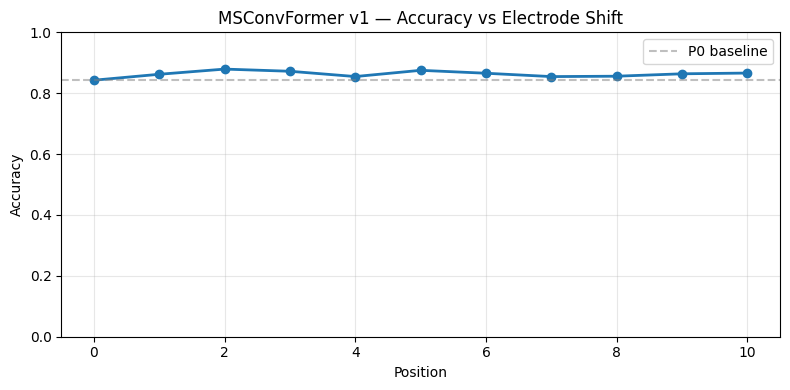

In [12]:
shift_subjects = [f"h{i}" for i in range(24, 30)]
shift_data = META[(META["subject"].isin(shift_subjects)) & (META["session"] == 0)]

s7_acc = {}
for pos in sorted(shift_data["position"].unique()):
    pos_df = shift_data[shift_data["position"] == pos]
    X_p, y_p, _ = load_and_norm(pos_df, stats=norm_stats)
    s7_acc[pos] = accuracy_score(y_p, base_predict(X_p))
    print(f"  Position {pos:2d}: {s7_acc[pos]:.4f}")

baseline = s7_acc.get(0, 0)
avg_shifted = np.mean([s7_acc[p] for p in s7_acc if p > 0])
print(f"\nP0 baseline: {baseline:.4f}, Avg shifted: {avg_shifted:.4f}, "
      f"Degradation: {(baseline - avg_shifted) * 100:.2f}%")

plt.figure(figsize=(8, 4))
plt.plot(list(s7_acc.keys()), list(s7_acc.values()), "o-", linewidth=2)
plt.axhline(y=baseline, color="gray", linestyle="--", alpha=0.5, label="P0 baseline")
plt.xlabel("Position")
plt.ylabel("Accuracy")
plt.title("MSConvFormer v1 — Accuracy vs Electrode Shift")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / "msconvformer_v1_shift.png"), dpi=150)
plt.show()

## S8: Few-Shot Calibration

In [13]:
subset_s8 = META[(META["session"] == 0) & (META["subject"].isin(TEST_SUBJECTS))]

configs = [
    ("Zero-shot",        [],     False, 0),
    ("1 rep, p0 only",   [0],    True,  7),
    ("1 rep, all pos",   [0],    False, 77),
    ("2 rep, p0 only",   [0, 1], True,  14),
    ("2 rep, all pos",   [0, 1], False, 154),
]

s8_results = {}
for label, reps, p0_only, n_trials in configs:
    cal_accs = []
    for subj in TEST_SUBJECTS:
        sdf = subset_s8[subset_s8["subject"] == subj]
        if len(reps) == 0:
            X_t, y_t, _ = load_and_norm(sdf, stats=norm_stats)
            cal_accs.append(accuracy_score(y_t, base_predict(X_t)))
            continue
        if p0_only:
            cal_df = sdf[(sdf["repetition"].isin(reps)) & (sdf["position"] == 0)]
        else:
            cal_df = sdf[sdf["repetition"].isin(reps)]
        te_df = sdf[sdf["repetition"] == 2]
        if len(cal_df) == 0 or len(te_df) == 0:
            continue
        X_c, y_c, _ = load_and_norm(cal_df, stats=norm_stats)
        X_t, y_t, _ = load_and_norm(te_df, stats=norm_stats)
        ft = finetune_fn(X_c, y_c)
        cal_accs.append(accuracy_score(y_t, ft(X_t)))
    s8_results[label] = np.mean(cal_accs) if cal_accs else float("nan")
    print(f"  {label:20s}: {s8_results[label]:.4f}  (~{n_trials} trials)")

  Zero-shot           : 0.6407  (~0 trials)
  1 rep, p0 only      : 0.6283  (~7 trials)
  1 rep, all pos      : 0.8602  (~77 trials)
  2 rep, p0 only      : 0.6910  (~14 trials)
  2 rep, all pos      : 0.8882  (~154 trials)


## Latency

In [14]:
sample = X_train[:1]

def single_predict(x):
    t = torch.FloatTensor(x).to(DEVICE)
    with torch.no_grad():
        return model(t).argmax(1).cpu().numpy()

latency = measure_latency(single_predict, sample, n_runs=500)
print_latency(latency, model_name="MSConvFormer v1")


Latency — MSConvFormer v1
  Mean:   3.30 ms
  Median: 2.95 ms
  P95:    5.02 ms
  <300ms: ✓


## Summary

In [15]:
print()
print("=" * 65)
print("  MSConvFormer v1 -- RESULTS")
print("=" * 65)
print(f"{'Scenario':<25s} {'Zero-shot':>10s} {'Calibrated':>12s} {'Delta':>10s}")
print("-" * 65)
pairs = [
    ("S1 Ideal", zero_results.get("S1", 0), cal_results.get("S1", 0)),
    ("S2 Shift", zero_results.get("S2", 0), cal_results.get("S2", 0)),
    ("S3 Inter-subject", zero_results.get("S3", 0), cal_results.get("S3", 0)),
    ("S4 Inter-day", zero_results.get("S4", 0), cal_results.get("S4", 0)),
    ("S5 Fatigue", zero_results.get("S5", 0), cal_results.get("S5", 0)),
]
for name, zs, cal in pairs:
    d = cal - zs
    check = " ✓" if cal >= 0.85 else ""
    print(f"{name:<25s} {zs*100:>9.2f}% {cal*100:>11.2f}%{check} {d*100:>+9.2f}%")
print(f"{'S6 Combined':<25s} {s6_zs*100:>9.2f}% {s6_cal*100:>11.2f}% {(s6_cal-s6_zs)*100:>+9.2f}%")
print(f"{'S7 Gradual (avg shift)':<25s} {avg_shifted*100:>9.2f}% {'--':>12s} {'--':>10s}")
for label, val in s8_results.items():
    if label == "Zero-shot":
        continue
    print(f"{'S8 ' + label:<25s} {'--':>10s} {val*100:>11.2f}% {'--':>10s}")
print("-" * 65)
print(f"Parameters:  {total_params:,}")
print(f"Latency p95: {latency['p95_ms']:.2f} ms")
print("=" * 65)


  MSConvFormer v1 -- RESULTS
Scenario                   Zero-shot   Calibrated      Delta
-----------------------------------------------------------------
S1 Ideal                      66.30%       84.85%    +18.55%
S2 Shift                      63.86%       85.02% ✓    +21.17%
S3 Inter-subject              64.08%       88.82% ✓    +24.74%
S4 Inter-day                  75.59%       87.79% ✓    +12.20%
S5 Fatigue                    83.69%       89.54% ✓     +5.86%
S6 Combined                   63.86%       89.39%    +25.54%
S7 Gradual (avg shift)        86.50%           --         --
S8 1 rep, p0 only                 --       62.83%         --
S8 1 rep, all pos                 --       86.02%         --
S8 2 rep, p0 only                 --       69.10%         --
S8 2 rep, all pos                 --       88.82%         --
-----------------------------------------------------------------
Parameters:  319,604
Latency p95: 5.02 ms


In [16]:
print("Model saved at:", MODEL_PATH)
print("Done.")

Model saved at: /Users/erdiantiwigaputriandini/Documents/Kuliah/Tugas Akhir/04. TA/02. Code/Tugas-Akhir/results/models/msconvformer_v1.pt
Done.
